## 电商用户行为分析与用户价值分层项目 

## 项目背景

基于电商用户行为数据，对用户浏览、收藏、加购、购买等行为进行分析，
探索用户购买转化路径、商品类别表现以及用户价值差异，
为电商运营和精准营销提供数据支持。

## 技术工具

- MySQL
- Python
- Pandas
- Matplotlib

## 分析内容

1. 用户行为分析
   - 用户行为分布分析

2. 用户购买漏斗分析
   - 浏览、收藏、加购、购买转化分析

3. 商品类别分析
   - 商品浏览Top10
   - 商品购买Top10
   - 商品类别转化率分析

4. RFM用户价值分析
   - 用户评分
   - 用户分层

# 1. 数据库连接

In [4]:
import pymysql
import pandas as pd

In [5]:
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='19880416Zyl',
    database='ecommerce_analysis',
    charset='utf8'
)
print("连接成功")

连接成功


# 2. 用户行为分析

## 2.1 用户行为数据读取

In [6]:
sql = """
select *
from user_behavior
limit 10;
"""

df = pd.read_sql(sql, conn)
df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3780\2085498767.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


,user_id,item_id,category_id,behavior,timestamp
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146
5,1,4606018,2735466,pv,1511616481
6,1,230380,411153,pv,1511644942
7,1,3827899,2920476,pv,1511713473
8,1,3745169,2891509,pv,1511725471
9,1,1531036,2920476,pv,1511733732


In [7]:
sql = """
select *
from behavior_summary;
"""

behavior_df = pd.read_sql(sql, conn)
behavior_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3780\2803059200.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  behavior_df = pd.read_sql(sql, conn)


,behavior,behavior_count
0,buy,2016785
1,cart,5532995
2,fav,2889368
3,pv,89757942


## 2.2 用户行为分布分析

In [8]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    

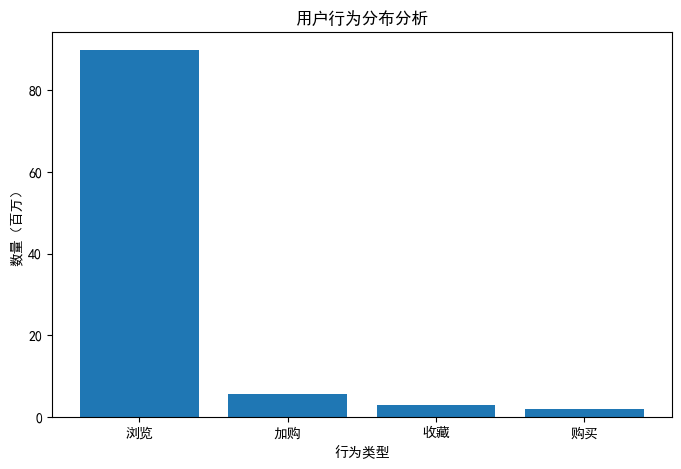

In [9]:
import matplotlib.pyplot as plt


behavior_plot = behavior_df.copy()


behavior_plot = behavior_plot.sort_values(
    "behavior_count",
    ascending=False
)


behavior_plot["behavior_count_million"] = (
    behavior_plot["behavior_count"] / 1000000
)


behavior_plot["behavior"] = behavior_plot["behavior"].replace({
    "pv":"浏览",
    "fav":"收藏",
    "cart":"加购",
    "buy":"购买"
})


plt.figure(figsize=(8,5))

plt.bar(
    behavior_plot["behavior"],
    behavior_plot["behavior_count_million"]
)

plt.title("用户行为分布分析")

plt.xlabel("行为类型")

plt.ylabel("数量（百万）")
plt.savefig(
    "../images/behavior_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 3. 用户购买漏斗分析

In [10]:
sql = """
select *
from user_funnel_summary;
"""
funnel_df = pd.read_sql(sql, conn)
funnel_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3780\3871152636.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  funnel_df = pd.read_sql(sql, conn)


,behavior,user_count
0,buy,672404
1,cart,738996
2,fav,389823
3,pv,984114


## 3.1 用户行为阶段统计

In [11]:
funnel_plot = funnel_df.copy()
funnel_plot["behavior"] = pd.Categorical(
    funnel_plot["behavior"],
    categories=["pv", "fav", "cart", "buy"],
    ordered=True
)
funnel_plot = funnel_plot.sort_values("behavior")
funnel_plot["behavior_cn"] = funnel_plot["behavior"].replace({
    "pv": "浏览",
    "fav": "收藏",
    "cart": "加购",
    "buy": "购买"
})
funnel_plot
    

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3780\1915872612.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  funnel_plot["behavior_cn"] = funnel_plot["behavior"].replace({


,behavior,user_count,behavior_cn
3,pv,984114,浏览
2,fav,389823,收藏
1,cart,738996,加购
0,buy,672404,购买


## 3.2 用户转化漏斗可视化

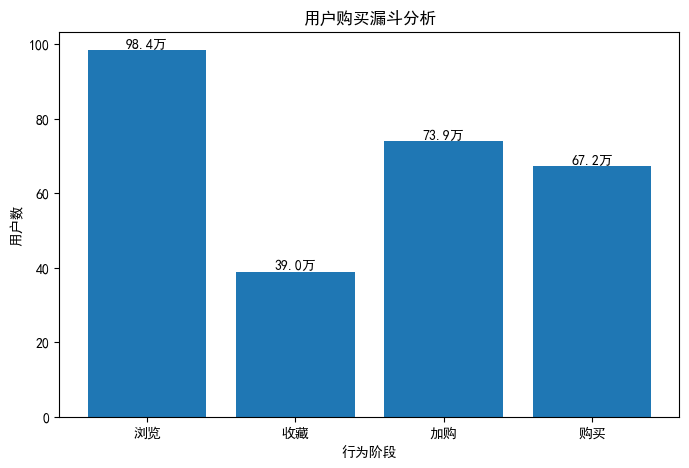

In [24]:
plt.figure(figsize=(8,5))
bars = plt.bar(
    funnel_plot["behavior_cn"],
    funnel_plot["user_count"]/10000
)
plt.title("用户购买漏斗分析")
plt.xlabel("行为阶段")
plt.ylabel("用户数")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'{height:.1f}万',
        ha='center',
        va='bottom'
    )
    plt.savefig(
    "../images/funnel_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 4. 商品类别分析

In [13]:
pv_user = funnel_plot.loc[
    funnel_plot["behavior"] =="pv", "user_count"
    ].values[0]
funnel_plot["conversion_rate"] = (
    funnel_plot["user_count"] / pv_user * 100
)
funnel_plot

,behavior,user_count,behavior_cn,conversion_rate
3,pv,984114,浏览,100.000000
2,fav,389823,收藏,39.611569
1,cart,738996,加购,75.092520
0,buy,672404,购买,68.325824


In [14]:
sql = """
select *
from category_view_summary
order by view_user desc
limit 10;
"""
category_view_df  = pd.read_sql(sql, conn)
category_view_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3780\2760375054.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_view_df  = pd.read_sql(sql, conn)


,category_id,view_user
0,4756105,410589
1,982926,392908
2,4145813,368668
3,2355072,361923
4,1320293,344100
5,3607361,331865
6,4801426,321491
7,2520377,297350
8,2465336,262648
9,3002561,255877


## 4.1 商品类别浏览用户Top10

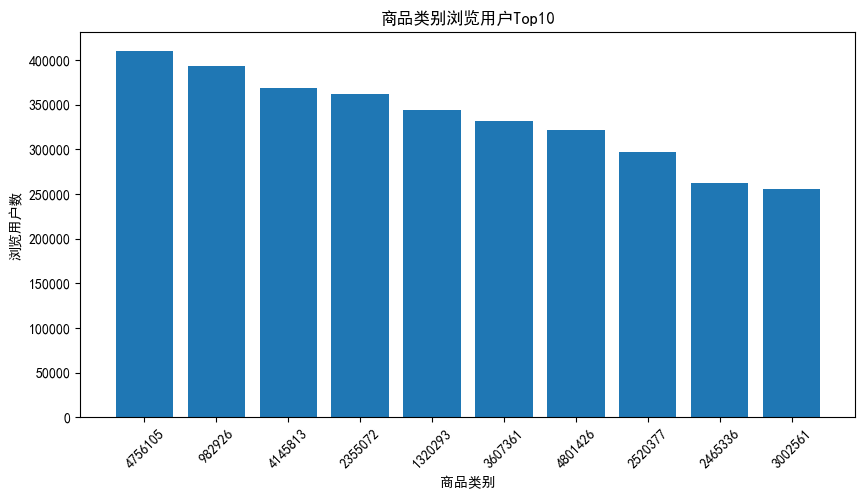

In [27]:
plt.figure(figsize=(10,5))
plt.bar(
    category_view_df["category_id"].astype(str),
    category_view_df["view_user"]
)
plt.title("商品类别浏览用户Top10")
plt.xlabel("商品类别")
plt.ylabel("浏览用户数")
plt.xticks(rotation=45)
plt.savefig(
    "../images/category_view_user_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.2 商品类别购买用户Top10

In [16]:
sql = """
select *
from category_buy_summary
order by buy_user desc
limit 10;
"""
category_buy_df  = pd.read_sql(sql, conn)
category_buy_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3780\2100032808.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_buy_df  = pd.read_sql(sql, conn)


,category_id,buy_user
0,1464116,29953
1,2735466,28759
2,4145813,27529
3,2885642,27118
4,4756105,23754
5,4801426,22725
6,982926,21190
7,4159072,15610
8,1320293,14903
9,3002561,14669


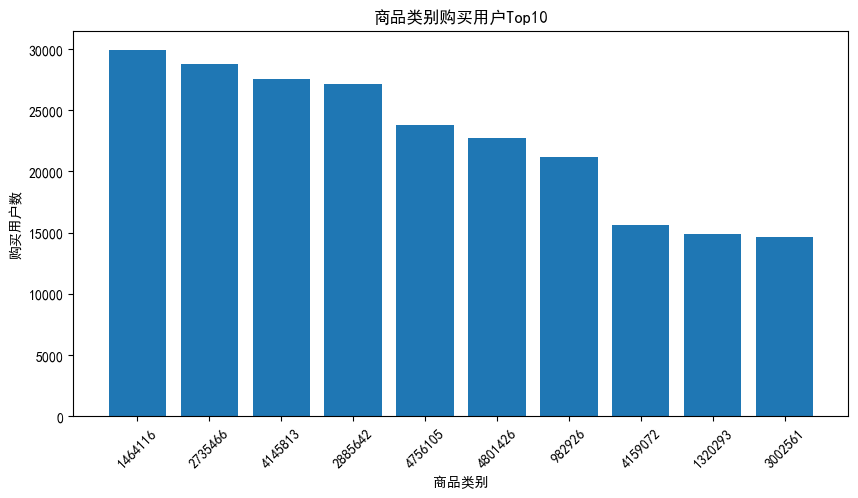

In [26]:
plt.figure(figsize=(10,5))
plt.bar(
    category_buy_df["category_id"].astype(str),
    category_buy_df["buy_user"]
)
plt.title("商品类别购买用户Top10")
plt.xlabel("商品类别")
plt.ylabel("购买用户数")
plt.xticks(rotation=45)
plt.savefig(
    "../images/category_buy_user_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.3 商品类别转化率分析

In [18]:
conversion_df = pd.read_sql("""
SELECT
    category_id,
    view_user,
    buy_user,
    round(
    buy_user / view_user * 100,
    2
    ) as conversion_rate
FROM category_conversion_v2
WHERE view_user >= 1000
ORDER BY conversion_rate DESC
LIMIT 10;
""", conn)


conversion_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3780\1445783437.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  conversion_df = pd.read_sql("""


,category_id,view_user,buy_user,conversion_rate
0,194104,1102,943,85.57
1,1421972,1500,1233,82.20
2,804084,2205,1552,70.39
3,4392650,2596,1105,42.57
4,63690,1690,702,41.54
5,937407,1032,423,40.99
6,2812993,1863,756,40.58
7,2925636,1009,404,40.04
8,1508018,1879,719,38.27
9,3900668,1483,541,36.48


In [19]:
conn.close()

In [20]:
import pymysql
import pandas as pd

conn = pymysql.connect(
    host='localhost',
    user='root',
    password='19880416Zyl',
    database='ecommerce_analysis',
    charset='utf8'
)

print("连接成功")

连接成功


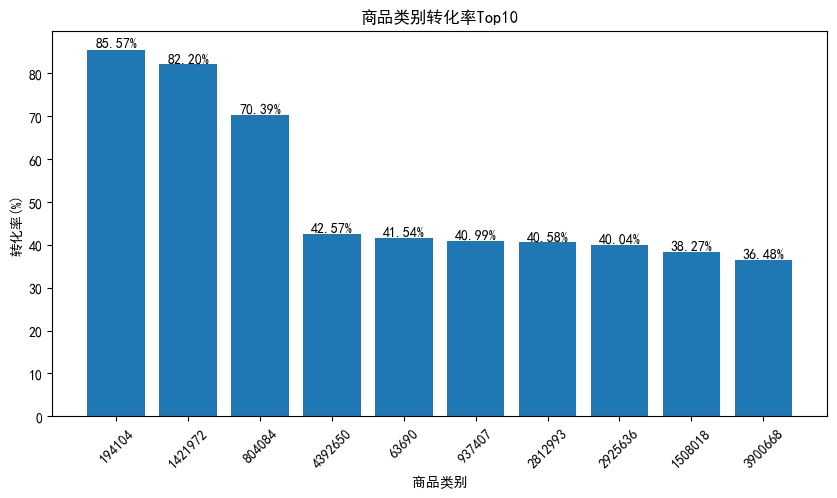

In [28]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    conversion_df["category_id"].astype(str),
    conversion_df["conversion_rate"]
)

plt.title("商品类别转化率Top10")

plt.xlabel("商品类别")

plt.ylabel("转化率(%)")

plt.xticks(rotation=45)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )
plt.savefig(
    "../images/category_conversion_rate_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. RFM用户价值分析

## 5.1 用户RFM数据读取与用户价值分层统计

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


sql = """
SELECT
    user_type,
    COUNT(*) AS user_count
FROM user_segment
GROUP BY user_type
ORDER BY user_count DESC;
"""


user_segment_df = pd.read_sql(sql, conn)

user_segment_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3780\2734131789.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  user_segment_df = pd.read_sql(sql, conn)


,user_type,user_count
0,潜力用户,447491
1,高价值用户,118598
2,流失风险用户,90440
3,一般用户,15875


## 5.2 用户价值分布可视化

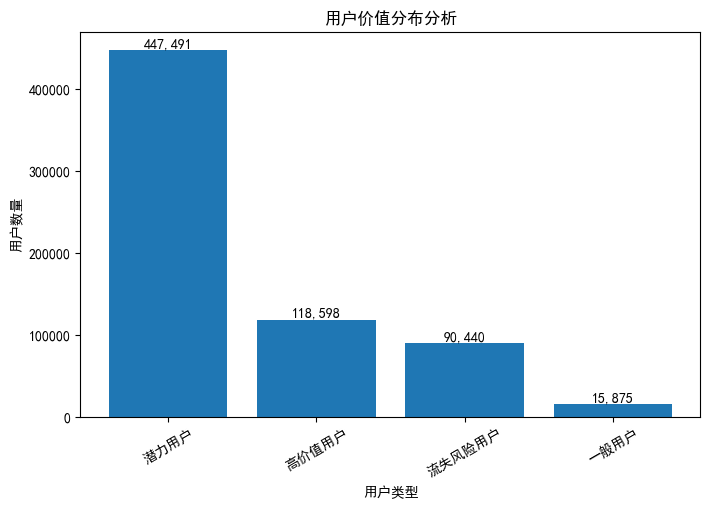

In [29]:
plt.figure(figsize=(8,5))


bars = plt.bar(
    user_segment_df["user_type"],
    user_segment_df["user_count"]
)


plt.title("用户价值分布分析")

plt.xlabel("用户类型")

plt.ylabel("用户数量")


plt.xticks(rotation=30)



for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.savefig(
    "../images/user_value_segmentation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. 项目总结

## 6.1 分析结论

1. 用户行为分析

通过对用户浏览、收藏、加购、购买行为进行分析发现，用户行为主要集中在浏览阶段，浏览量明显高于后续购买行为，说明用户从访问商品到最终购买过程中存在一定流失，需要进一步优化商品展示、推荐策略以及购买流程。


2. 用户购买漏斗分析

通过构建用户购买漏斗，对浏览、收藏、加购和购买阶段进行转化分析，发现不同阶段用户数量逐步减少，可以针对低转化环节进行优化，提高用户购买转化率。


3. 商品类别分析

通过分析不同商品类别的浏览量、购买用户数量以及转化率，识别出具有较高用户关注度和购买潜力的商品类别，为商品推荐、运营推广和资源配置提供参考。


4. 用户价值分析

基于RFM模型对用户进行价值分层，将用户划分为高价值用户、潜力用户、流失风险用户和一般用户。通过用户分层，可以针对不同用户群体制定差异化运营策略，提高用户留存和复购率。


## 6.2 项目总结

本项目基于电商用户行为数据，使用MySQL完成数据清洗与统计分析，并结合Python（Pandas、Matplotlib）进行数据处理和可视化展示。

通过用户行为分析、购买漏斗分析、商品类别分析以及RFM用户价值分析，全面探索用户行为特征和用户价值差异，为电商运营优化和精准营销提供数据支持。